# Multiple Strains

# Parameters

#Agent class

In [ ]:
import numpy as np
import random

class Agent:
    def __init__(self, num_strains, infection_params, immunity_params,infection_probabilities):
        self.infected = [False] * num_strains  # List to track infection status for each strain
        self.immune = [False] * num_strains  # List to track immunity status for each strain
        self.remaining_days_of_infection = [self.random_days(mean, std) for mean, std in infection_params]
        self.remaining_days_of_immunity = [self.random_days(mean, std) for mean, std in immunity_params]
        self.susceptible = True
        self.infection_probabilities = infection_probabilities.copy()  # Copy to ensure independence
    def random_days(self, mean, std):
        return max(0, int(np.random.normal(mean, std)))


#Picking two random agents

In [ ]:
import random
def PickTwoAgentsWithContacts(numAgents):
    """
    Randomly selects two different agent indices from the range [0, numAgents-1]
    with a probability of being in contact.

    Parameters:
    - numAgents (int): The total number of agents.
    - contact_prob (float): The probability of two agents being in contact.

    Returns:
    - tuple: A tuple containing two distinct agent indices.
    """
    # Randomly select two initial indices
    index1 = random.randint(0, numAgents - 1)
    index2 = random.randint(0, numAgents - 1)

    # Ensure the selected indices are different
    while index1 == index2 :
        index1 = random.randint(0, numAgents - 1)
        index2 = random.randint(0, numAgents - 1)

    return index1, index2

## `start_step` Function



In [ ]:
import numpy as np
import random


def start_step(number_of_agents, num_strains, infected_at_start, infection_params, immunity_params,infection_probabilities):
    if sum(infected_at_start) > number_of_agents:
        raise ValueError("Total number of initially infected agents exceeds the total number of agents.")

    agents = []

    # Create agents
    for i in range(number_of_agents):
        agents.append(Agent(num_strains, infection_params, immunity_params,infection_probabilities))

    # Infect agents according to infected_at_start array
    for strain_index in range(num_strains):
        infected_indices = random.sample(range(number_of_agents), infected_at_start[strain_index])
        for index in infected_indices:
            agents[index].infected[strain_index] = True
            agents[index].remaining_days_of_infection[strain_index] = max(0, int(np.random.normal(infection_params[strain_index][0], infection_params[strain_index][1])))
            agents[index].susceptible = False

    return agents


#infect function

In [ ]:
import random
import numpy as np

def infect(agent1, agent2, infection_probabilities):
    for strain_index in range(len(infection_probabilities)):
        random_number = random.random()
        if not agent1.infected[strain_index] and agent2.infected[strain_index] and not agent1.immune[strain_index] and random_number < agent1.infection_probabilities[strain_index]:
            agent1.infected[strain_index] = True
            agent1.remaining_days_of_infection[strain_index] =max(0, int(np.random.normal(infection_params[strain_index][0], infection_params[strain_index][1])))
            agent1.susceptible = False
        elif not agent2.infected[strain_index] and agent1.infected[strain_index] and not agent2.immune[strain_index] and random_number < agent2.infection_probabilities[strain_index]:
            agent2.infected[strain_index] = True
            agent2.remaining_days_of_infection[strain_index] = max(0, int(np.random.normal(infection_params[strain_index][0], infection_params[strain_index][1])))
            agent2.susceptible = False

    return agent1, agent2


#Birth And Death

In [ ]:
import numpy as np
def remove_dead_agents(agents, num_dead_agents):
    if num_dead_agents >= len(agents):
        agents.clear()
    else:
        for _ in range(num_dead_agents):
            index = random.randint(0, len(agents) - 1)
            agents.pop(index)
    return agents

def create_new_agents(agents, num_new_agents, infected_per_birth_duration, infection_params, immunity_params, infection_probabilities,birth_duration):
    num_strains = len(infection_params)  # Assuming all agents have the same number of strains

    if len(infected_per_birth_duration) != num_strains:
        raise ValueError("Length of infected_per_birth_duration must match the number of strains.")

    for i in range(num_new_agents):
        new_agent = Agent(num_strains, infection_params, immunity_params, infection_probabilities)

        for strain_index in range(num_strains):
            number=np.random.poisson(infected_per_birth_duration[strain_index]/birth_duration)
            if i < number:
                new_agent.infected[strain_index] = True

        agents.append(new_agent)

    return agents


In [ ]:
import numpy as np

def Birth_death(agents, birth_pulse, birth_rate_yearly, birth_interval, birth_duration, new_born, deads,carrying_capacity,infection_probabilities):
    num_new_agents = 0
    num_dead_agents = 0
    b = 0.1
    m=(birth_rate_yearly-b)/int(len(agents))



    # Check if the birth pulse matches the birth interval
    if birth_pulse % birth_interval < birth_duration:
        # Calculate the expected number of new agents over the birth duration
        expected_new_agents_over_duration = birth_rate_yearly * len(agents)

        # Generate the number of new agents using Poisson distribution
        num_new_agents = np.random.poisson(expected_new_agents_over_duration/birth_duration)

        # Create new agents with the specified parameters
        agents = create_new_agents(agents, num_new_agents, infected_per_birth_duration, infection_params, immunity_params, infection_probabilities,birth_duration)

    # Calculate daily death rate
    death_rate = m * len(agents) + b

    daily_death_rate=death_rate/birth_interval


    # Generate the number of dead agents using binomial distribution
    num_dead_agents = np.random.binomial(len(agents), daily_death_rate)

    # Remove dead agents
    agents = remove_dead_agents(agents, num_dead_agents)

    return agents, num_new_agents, num_dead_agents

# Updating parameters method

In [ ]:
import pandas as pd
import numpy as np

def update_params(agents):
    num_strains = len(agents[0].infected)  # Assuming all agents have the same number of strains
    Overall_infected = [0] * num_strains  # List to track infected agents for each strain
    susceptibles = 0

    # List to collect debug information
    debug_info = []

    for agent_idx, agent in enumerate(agents):
        agent_debug_info = {
            "Agent": agent_idx,
            "Strains Infected": [],
            "Strains Immune": [],
            "Infection Probabilities Before": [],
            "Infection Probabilities After": []
        }

        for strain_index in range(num_strains):
            if agent.infected[strain_index]:
                agent.remaining_days_of_infection[strain_index] -= 1

                if agent.remaining_days_of_infection[strain_index] < 0:
                    # Infection duration ended
                    before_probs = agent.infection_probabilities.copy()
                    agent.infected[strain_index] = False
                    agent.immune[strain_index] = True
                    agent.remaining_days_of_immunity[strain_index] = np.random.normal(immunity_params[strain_index][0], immunity_params[strain_index][1])

                    # Update infection probabilities only for the current agent
                    for idx in range(num_strains):
                        if idx != strain_index:
                            agent.infection_probabilities[idx] *= after_recovery_factors[strain_index]


            elif agent.immune[strain_index]:
                agent.remaining_days_of_immunity[strain_index] -= 1

                if agent.remaining_days_of_immunity[strain_index] < 0:
                    # Immunity duration ended
                    before_probs = agent.infection_probabilities.copy()
                    agent.immune[strain_index] = False
                    agent.susceptible = True

                    # Update infection probabilities only for the current agent
                    for idx in range(num_strains):
                        if idx != strain_index:
                              agent.infection_probabilities[idx] /= after_recovery_factors[strain_index]



        for strain_index in range(num_strains):
            if agent.infected[strain_index]:
                Overall_infected[strain_index] += 1
        if agent.susceptible:
            susceptibles += 1



    return agents, Overall_infected, susceptibles


# Simulation

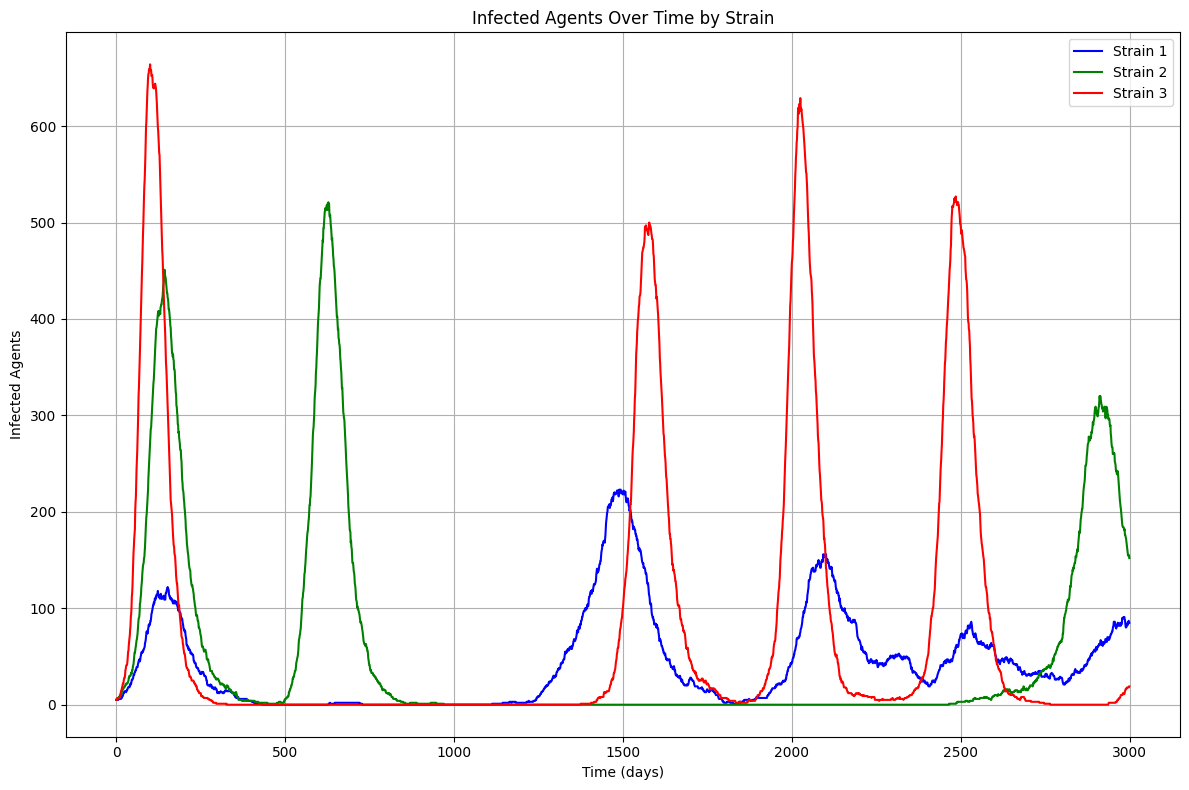

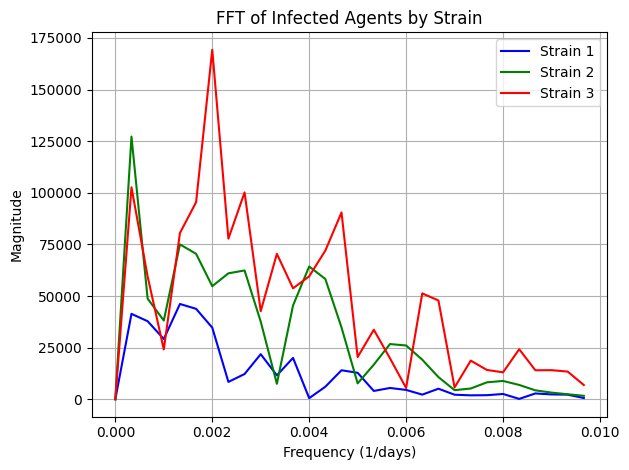

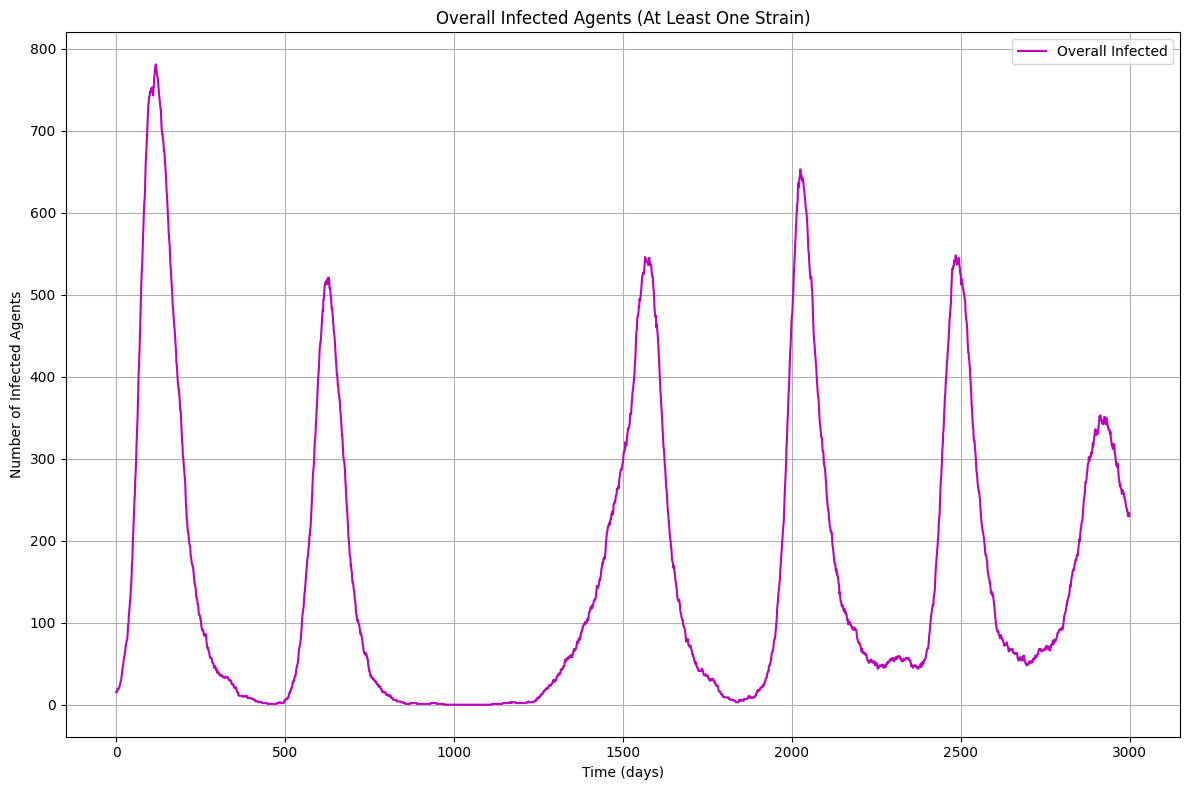

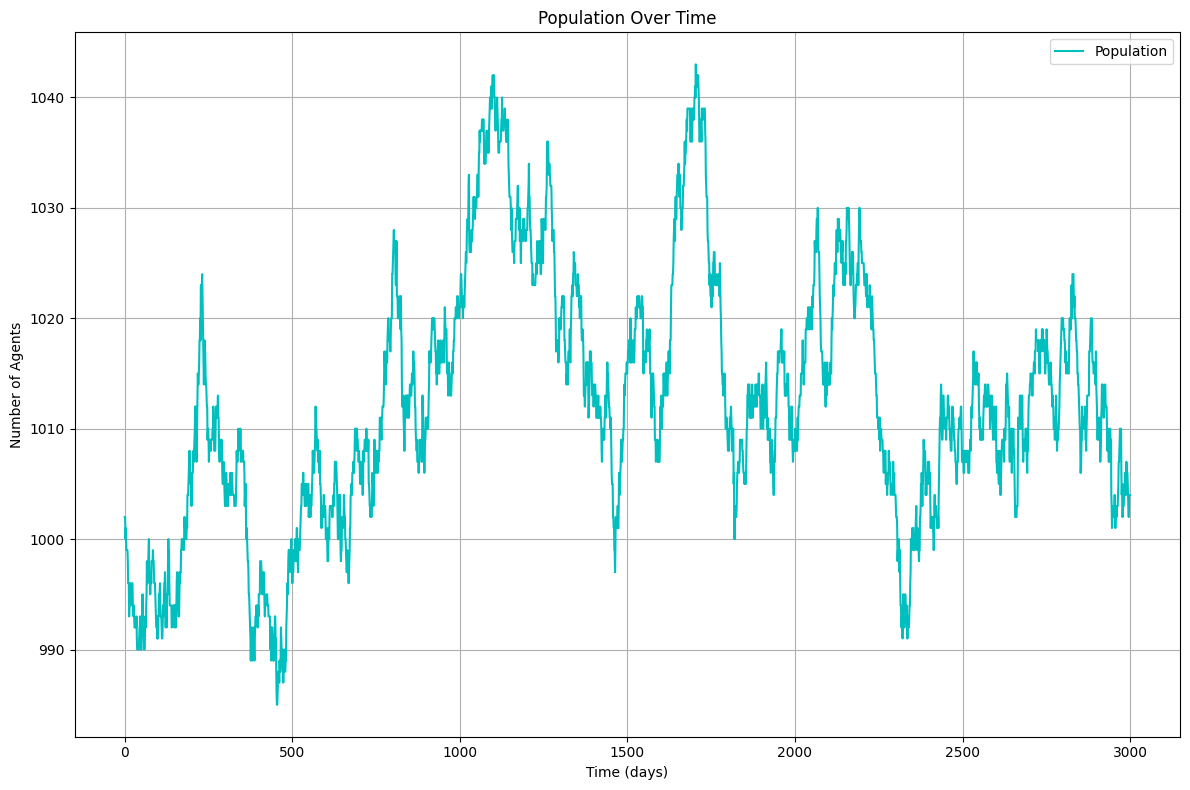

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fftpack
# from scipy.signal import find_peaks

%matplotlib inline

def random_days1(mean, std):
    return max(0, int(np.random.normal(mean, std)))

num_agents = 1000
num_strains = 3
infected_at_start = [5,5,5]  # Number of initially infected agents for each strain
infection_params = [(60,20),(60,20),(60,20)]  # (mean, std) for infection periods for each strain
immunity_params = [ (280, 30),  (280, 30), (280, 30)]  # (mean, std) for immunity periods for each strain
infected_per_birth_duration = [1,1,1]
after_recovery_factors = [0.5,0.5,0.5]
R0 = [2,3,4]
number_of_interactions_per_day_per_agent = 1 / 10
infection_probabilities = [0] * num_strains

# Loop through each strain's infection parameters
for idx, (mean, std) in enumerate(infection_params):
    TMP = mean * number_of_interactions_per_day_per_agent
    infection_probabilities[idx] = (float(R0[idx]) / TMP)
    #print(f"Infection Probability for Strain {idx}: {infection_probabilities[idx]}")


simulation_duration1 = 3000
birth_rate_yearly = 0.3
birth_duration = 365
birth_interval = 365
carrying_capacity = 1000

agents = start_step(num_agents, num_strains, infected_at_start, infection_params, immunity_params, infection_probabilities)

number_of_interactions_per_day = int(len(agents) * number_of_interactions_per_day_per_agent // 2)
birth_pulse = 0
new_born = [0] * int(simulation_duration1)
deads = [0] * int(simulation_duration1)
population = [0] * int(simulation_duration1)
overAll_infected = [[] for _ in range(num_strains)]
overAll_infected_transform = [[] for _ in range(num_strains)]
overall_infected_combined = []
intersections = []
sus = [0] * int(simulation_duration1)

# Track the infection probabilities for a specific agent
specific_agent_infection_probs = []
pop=[0]*simulation_duration1
for i in range(simulation_duration1):
    for j in range(number_of_interactions_per_day):
        index1, index2 = PickTwoAgentsWithContacts(len(agents))
        infect(agents[index1], agents[index2], infection_probabilities)

    birth_pulse += 1
    agents, num_new_agents, num_dead_agents = Birth_death(agents, birth_pulse, birth_rate_yearly, birth_interval, birth_duration, new_born, deads, carrying_capacity,infection_probabilities)

    deads[i] = num_dead_agents
    new_born[i] = num_new_agents
    population[i] = len(agents)

    # Update agents and get current infected counts for each strain
    agents, overall_infected_current, susceptibles = update_params(agents)
    # print(agents[0].infection_probabilities)
    # Track the infection probabilities for the specific agent (e.g., the first agent in the list)
    if len(agents) > 0:
        specific_agent_infection_probs.append(agents[0].infection_probabilities.copy())

    # Accumulate infected counts for each strain
    for strain_index in range(num_strains):
        overAll_infected[strain_index].append(overall_infected_current[strain_index])

    # Calculate overall infected agents (infected in at least one strain)
    overall_infected_count = sum(1 for agent in agents if any(agent.infected))
    overall_infected_combined.append(overall_infected_count)
    pop[i]=len(agents)


# Plotting each strain on the same plot with different colors
plt.figure(figsize=(12, 8))
colors = ['b', 'g', 'r']  # Different colors for different strains

for strain_index in range(num_strains):
   # overAll_infected_transform[strain_index]=scipy.fftpack.fft(overAll_infected[strain_index])
    plt.plot(range(simulation_duration1), overAll_infected[strain_index], color=colors[strain_index], label=f'Strain {strain_index + 1}')

plt.xlabel('Time (days)')
plt.ylabel('Infected Agents')
plt.title('Infected Agents Over Time by Strain')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


for strain_index in range(num_strains):
    # Perform FFT
    Y=overAll_infected[strain_index]
    Y_avg=np.mean(Y)
    Y1=Y-Y_avg
    fft_values = scipy.fftpack.fft(Y1)
    fft_magnitude = np.abs(fft_values)  # Magnitude of the FFT
    fft_freq = scipy.fftpack.fftfreq(len(overAll_infected[strain_index]))  # Frequencies

    # Plot only the positive frequencies
    positive_freq_indices = np.where((fft_freq >= 0) & (fft_freq < 0.01))
    plt.plot(fft_freq[positive_freq_indices], fft_magnitude[positive_freq_indices], color=colors[strain_index], label=f'Strain {strain_index + 1}')

plt.xlabel('Frequency (1/days)')
plt.ylabel('Magnitude')
plt.title('FFT of Infected Agents by Strain')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Plotting overall infected agents over time with zoom and pan capabilities
plt.figure(figsize=(12, 8))
plt.plot(range(simulation_duration1), overall_infected_combined, color='m', label='Overall Infected')
plt.xlabel('Time (days)')
plt.ylabel('Number of Infected Agents')
plt.title('Overall Infected Agents (At Least One Strain)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# %peaks = find_peaks(fft_values)
# %print(fft_freq[peaks])

# Plotting overall population over time
plt.figure(figsize=(12, 8))
plt.plot(range(simulation_duration1), pop, color='c', label='Population')
plt.xlabel('Time (days)')
plt.ylabel('Number of Agents')
plt.title('Population Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

